# Distribuciones de probabilidad: ejemplo práctico

En la lección anterior entendimos qué es una distribución de probabilidad, así que en esta lección veremos de forma práctica este concepto.

Para ello tomaremos diferentes sets de datos y, haciendo uso de herramientas de Python y de librerías como Pandas y Seaborn, obtendremos e interpretaremos las gráficas de las diferentes distribuciones.

Comencemos importando las librerías necesarias:

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns
sns.set_theme() # Establecer tema por defecto para los gráficos

## 1. Set de datos `alturas.csv`

Este set de datos contiene el registro de 200 datos de alturas medidas a partir de un grupo de 100 hombres y 100 mujeres.

Comencemos leyendo este set de datos usando la librería Pandas:

In [2]:
# Ruta
RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/17-2023-11-ProbabilidadNivelIntermedio/ProbabilidadNivelIntermedio-data/'

# Lectura
df_alt = pd.read_csv(RUTA + 'alturas.csv')
df_alt

,altura (m),género
0,1.71,Masculino
1,1.49,Femenino
2,1.74,Masculino
3,1.71,Masculino
4,1.54,Femenino
...,...,...
195,1.71,Femenino
196,1.57,Masculino
197,1.63,Femenino
198,1.78,Femenino


Vemos que por cada persona tenemos la altura (en metros) y su correspondiente género.

En la práctica, muchas veces resulta imposible obtener una función que permita calcular analíticamente la distribución de probabilidad.

En lugar de esto se recurre al **histograma**:

> Un histograma permite representar gráficamente la **distribución** de un conjunto de datos.

En el eje horizontal de esta gráfica tendremos la **variable de interés** (en este caso la altura) y en el eje vertical tendremos el **conteo** de observaciones dentro de un intervalo.

Por ejemplo, creemos un sencillo histograma correspondiente a la columna `altura (m)`:

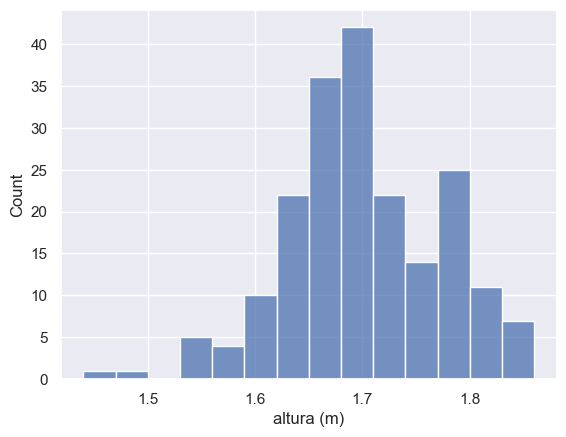

In [3]:
# Histograma básico (sin diferenciar géneros)

ax = sns.histplot(df_alt['altura (m)'])

En la gráfica anterior, Seaborn ha dividido la variable alturas en un cierto número de intervalos o *bins* (en este caso 14) y para cada *bin* ha realizado simplemente un conteo de cuántas personas tienen altura dentro de este rango.

Por ejemplo, vemos que alrededor de 1.7 m tenemos la mayoría de las personas (un poco más de 40), mientras que un pequeño grupo de personas tiene alturas por debajo de 1.5.

Si queremos usar rangos más pequeños simplemente podemos usar el parámetro *bins*:

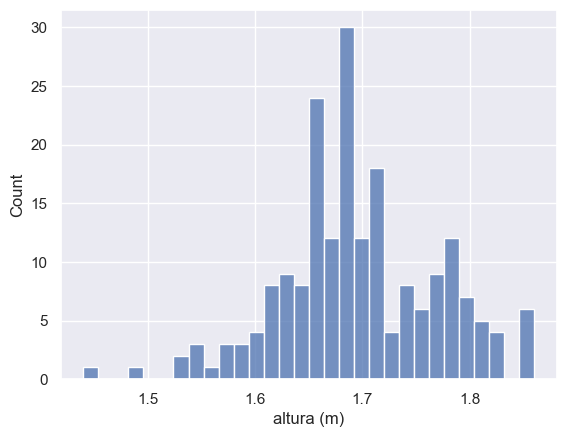

In [4]:
ax = sns.histplot(df_alt['altura (m)'], bins=30)

Pero hasta este punto la variable del eje vertical es simplemente el conteo (`Count`).

Pero nos interesa conocer la distribución de probabilidad. Es decir nos interesa saber cuál es la probabilidad de ocurrencia de cada *bin*.

Esto es fácil de hacer, por cada *bin*

1. Tomamos el conteo correspondiente al *bin*
2. Y lo dividimos entre el número total de datos en el dataset

Por ejemplo, si un *bin* tiene un valor de 30 (30 personas tienen altura dentro de ese intervalo), entonces su probabilidad de ocurrencia será 30/2000 (que es el número total de personas en el set de datos) = 0.15

Y lo anterior se puede obtener fácilmente si simplemente usamos el argumento `stat = 'probability'`:

In [5]:
30/200

0.15

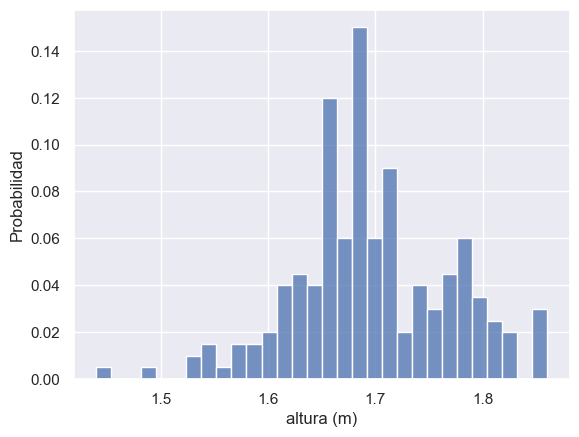

In [6]:
ax = sns.histplot(df_alt['altura (m)'], bins=30, stat='probability');
ax.set_ylabel('Probabilidad');

¡Y listo, hemos estimado la distribución de probabilidad de este set de datos!

Al dividir cada conteo entre el número total de datos estamos garantizando que al sumar todas las probabilidades mostradas en la distribución el resultado será exactamente igual a 1. Además, vemos que cada probabilidad está precisamente entre 0 y 1.

Y podemos seguir la misma lógica pero por ejemplo para comparar la distribución de probabilidad de mujeres vs. la de hombres:

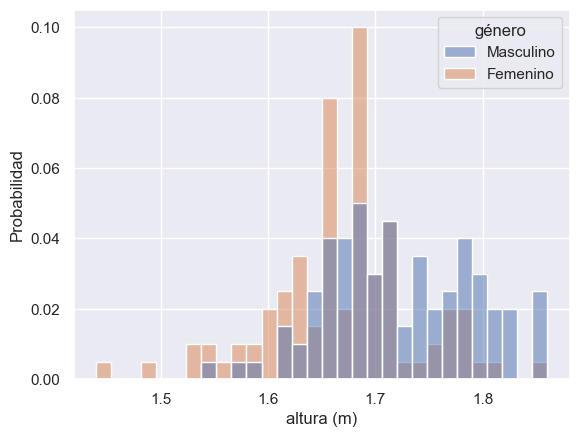

In [7]:
ax = sns.histplot(data=df_alt, x='altura (m)', hue='género', bins=30, stat='probability');
ax.set_ylabel('Probabilidad');

Y dependiendo del análisis que queramos hacer podríamos por ejemplo decir que las mujeres en general tienen una altura inferior a los hombres (y podríamos incluso aplicar pruebas estadísticas para verificar esta hipótesis).

## 2. Set de datos `temperaturas.csv`

Muy bien, ya tenemos las herramientas básicas para obtener la distribución de probabilidades de un set de datos a partir de histogramas. Así que para los ejemplos restantes usaremos esta misma lógica.



In [8]:
df_temps = pd.read_csv(RUTA + 'temperaturas.csv')
df_temps

,hora,temperatura (°C)
0,0,13.4
1,1,12.1
2,2,14.5
3,3,13.1
4,4,13.3
...,...,...
715,715,12.4
716,716,12.4
717,717,10.9
718,718,12.9


El set de datos contiene un registro de 30 días consecutivos (1 medición/hora) de la temperatura en un lugar determinado.

De nuevo, podemos obtener el histograma para ver la distribución de probabilidades:

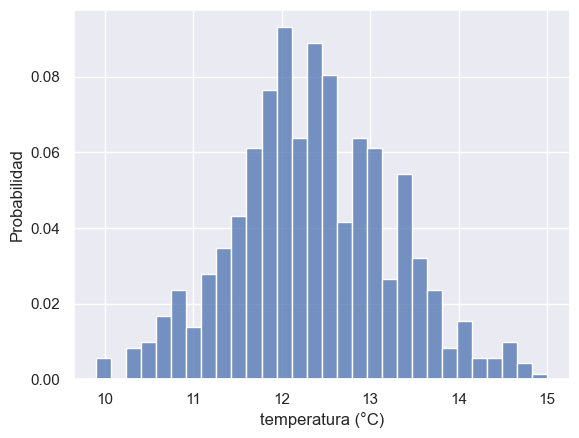

In [9]:
ax = sns.histplot(df_temps['temperatura (°C)'], bins=30, stat='probability');
ax.set_ylabel('Probabilidad');

## 3. Set de datos `spam.csv`

Este set de datos contiene la información recolectada para 1.000 e-mails. Por cada e-mail se incluye la categoría a la que pertenece: *no spam* (0) y *spam* (1):

In [10]:
df_spam = pd.read_csv(RUTA + 'spam.csv')
df_spam

,mensaje,cat,cat_num
0,1,spam,1
1,2,spam,1
2,3,spam,1
3,4,no spam,0
4,5,no spam,0
...,...,...,...
995,996,spam,1
996,997,spam,1
997,998,no spam,0
998,999,spam,1


Podemos obtener el histograma de la columna `cat` (categoría en formato texto) o `cat_num` (en formato numérico). Hagámoslo para `cat` (pues resulta más fácil de interpretar la gráfica):

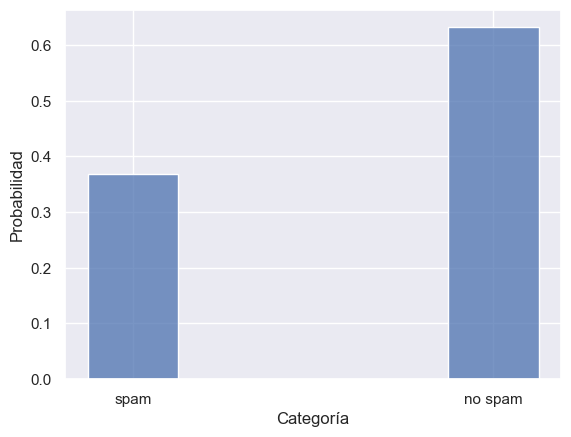

In [11]:
ax = sns.histplot(data=df_spam, x='cat', stat='probability', shrink=0.25)
ax.set_xlabel('Categoría')
ax.set_ylabel('Probabilidad');

Así por ejemplo, la categoría *no spam* tiene una probabilidad de ocurrencia de aproximadamente 0.62 (o 62%).

## 4. Set de datos `imagenes.csv`

Este set contiene el resultado de analizar una imagen de ecocardiografía para un total de 2000 sujetos. El resultado corresponde a una de estas cuatro categorías:

- *normal* (0)
- *anormal nivel 1* (1)
- *anormal nivel 2* (2)
- *anormal nivel 3* (3)

Carguemos el set de datos:

In [12]:
df_imgs = pd.read_csv(RUTA + 'imagenes.csv')
df_imgs

,sujeto,cat,cats_num
0,1,normal,0
1,2,normal,0
2,3,anormal nivel 1,1
3,4,anormal nivel 1,1
4,5,anormal nivel 3,3
...,...,...,...
1995,1996,anormal nivel 1,1
1996,1997,anormal nivel 3,3
1997,1998,anormal nivel 1,1
1998,1999,anormal nivel 2,2


Al igual que en el caso anterior, podemos graficar el histograma/distribución de la columna `cat` (categorías en formato texto) o `cats_num` (categorías en formato numérico).

Dibujemos en este caso la distribución de la columna `cats_num`:

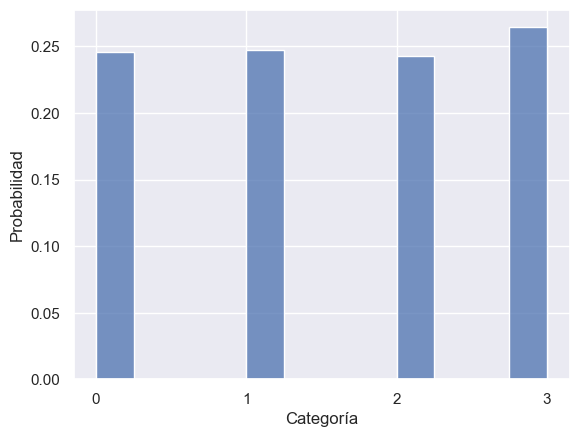

In [13]:
ax = sns.histplot(data=df_imgs, x='cats_num', stat='probability')
ax.set_xlabel('Categoría')
ax.set_ylabel('Probabilidad')
ax.set_xticks([0,1, 2, 3]);